In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score,ConfusionMatrixDisplay,RocCurveDisplay
import pickle

In [48]:
data = pd.read_csv('data/uci-ml-phishing-dataset.csv')

In [49]:
data.shape

(11055, 32)

In [50]:
data.sample(5)

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
4885,4886,1,-1,1,1,1,-1,1,-1,1,...,1,1,1,-1,1,-1,-1,0,1,-1
2744,2745,1,-1,1,1,1,-1,0,0,1,...,1,1,1,-1,-1,1,-1,1,1,-1
3876,3877,1,-1,1,1,1,-1,-1,-1,-1,...,1,1,-1,1,0,1,1,0,1,-1
3729,3730,1,-1,1,1,1,-1,0,1,-1,...,1,1,-1,1,0,-1,1,0,1,1
6454,6455,1,-1,1,1,1,-1,0,-1,-1,...,1,1,-1,1,-1,1,1,0,1,-1


In [51]:
data.nunique()

id                             11055
having_IP_Address                  2
URL_Length                         3
Shortining_Service                 2
having_At_Symbol                   2
double_slash_redirecting           2
Prefix_Suffix                      2
having_Sub_Domain                  3
SSLfinal_State                     3
Domain_registeration_length        2
Favicon                            2
port                               2
HTTPS_token                        2
Request_URL                        2
URL_of_Anchor                      3
Links_in_tags                      3
SFH                                3
Submitting_to_email                2
Abnormal_URL                       2
Redirect                           2
on_mouseover                       2
RightClick                         2
popUpWidnow                        2
Iframe                             2
age_of_domain                      2
DNSRecord                          2
web_traffic                        3
P

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           11055 non-null  int64
 1   having_IP_Address            11055 non-null  int64
 2   URL_Length                   11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [53]:
data.describe()

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,5528.000000,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,3191.447947,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2764.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5528.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8291.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
data.isnull().sum()

id                             0
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [55]:
data.duplicated().sum()

np.int64(0)

In [56]:
data.corr()['Result'].sort_values(ascending=False)

Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
port                           0.036419
Links_pointing_to_page         0.032574
Submitting_to_email            0.018249
RightClick                     0.012653
id                             0.000978
popUpWidnow                    0.000086
Favicon                       -0.000280


In [57]:
data.columns

Index(['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

## univariate analysis

<Axes: xlabel='Result', ylabel='count'>

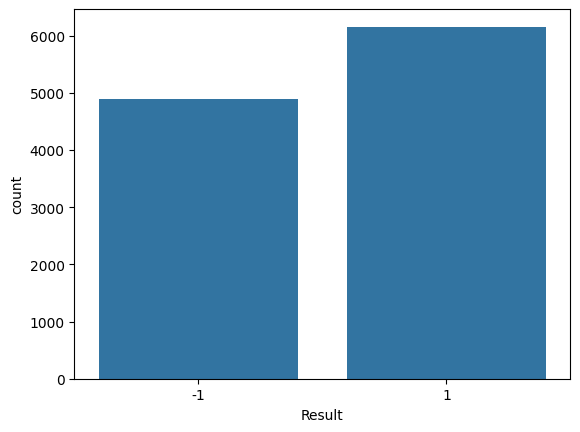

In [58]:
sns.countplot(data=data,x=data['Result'])

<Axes: ylabel='count'>

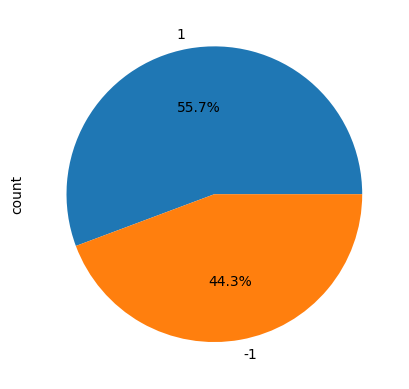

In [59]:
data['Result'].value_counts().plot(kind='pie',autopct='%1.01f%%')

<Axes: xlabel='SSLfinal_State', ylabel='count'>

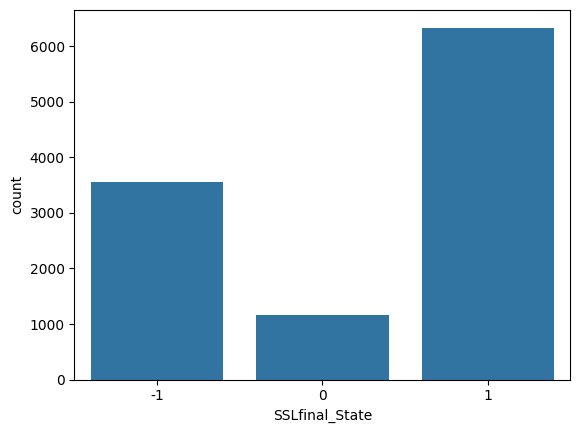

In [60]:
sns.countplot(data=data,x=data['SSLfinal_State'])

<Axes: ylabel='count'>

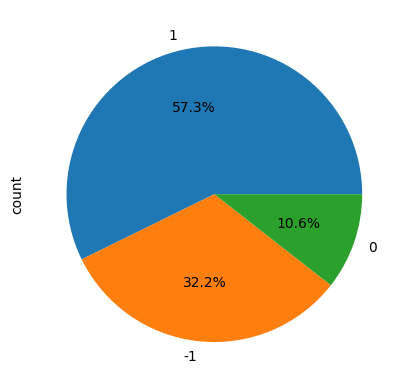

In [61]:
data['SSLfinal_State'].value_counts().plot(kind='pie',autopct='%1.01f%%') # a cirtificate which is issued when a url connects with a server using https and tls handshake

<Axes: xlabel='URL_of_Anchor', ylabel='count'>

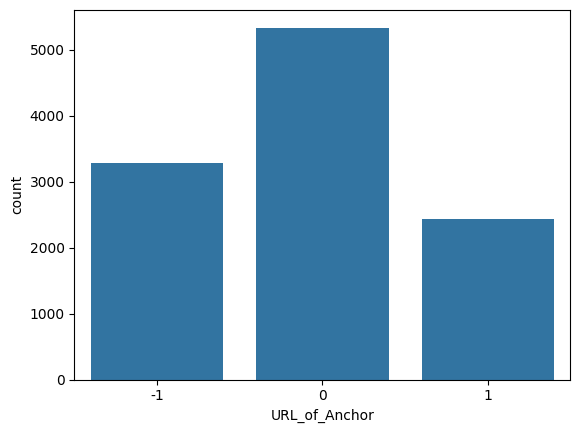

In [62]:
sns.countplot(data=data,x=data['URL_of_Anchor'])

<Axes: ylabel='count'>

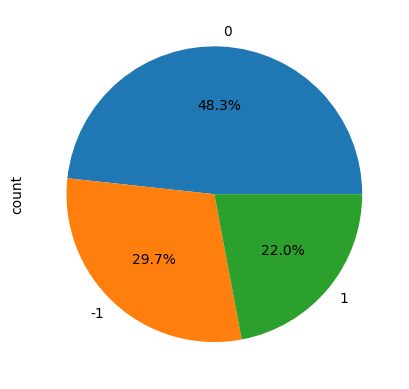

In [63]:
data['URL_of_Anchor'].value_counts().plot(kind='pie',autopct='%1.01f%%') # how many links are taking me to other domain

<Axes: xlabel='Prefix_Suffix', ylabel='count'>

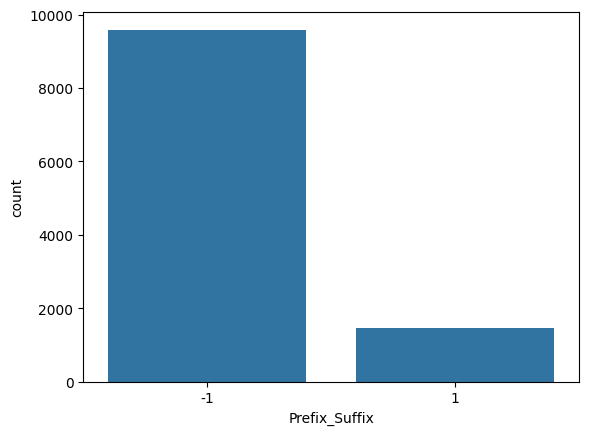

In [64]:
sns.countplot(data=data,x=data['Prefix_Suffix'])

<Axes: ylabel='count'>

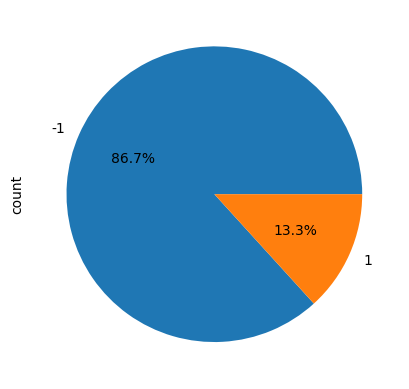

In [65]:
data['Prefix_Suffix'].value_counts().plot(kind='pie',autopct='%1.01f%%') # contains hyphen -

<Axes: xlabel='web_traffic', ylabel='count'>

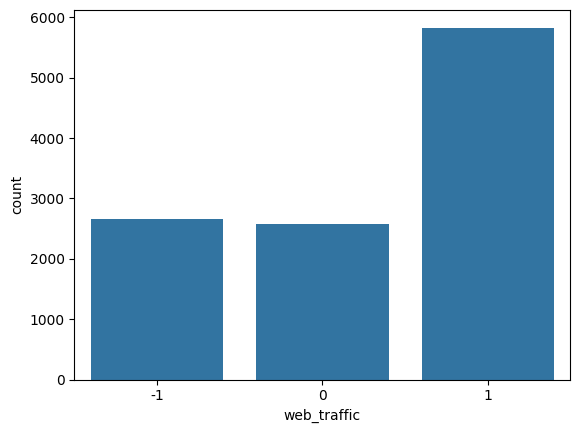

In [66]:
 sns.countplot(data=data,x=data['web_traffic'])

<Axes: ylabel='count'>

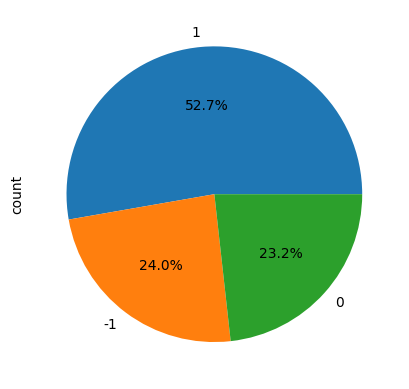

In [67]:
data['web_traffic'].value_counts().plot(kind='pie',autopct='%1.01f%%') # popularity of websites

<Axes: xlabel='having_Sub_Domain', ylabel='count'>

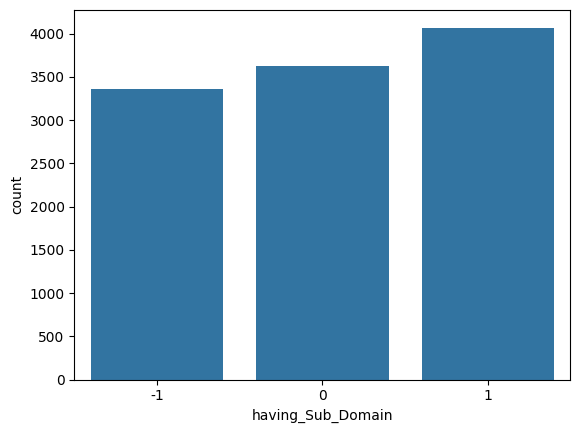

In [68]:
sns.countplot(data=data,x=data['having_Sub_Domain'])

<Axes: ylabel='count'>

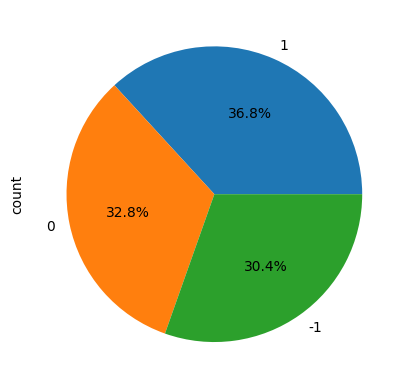

In [69]:
data['having_Sub_Domain'].value_counts().plot(kind='pie',autopct='%1.01f%%')

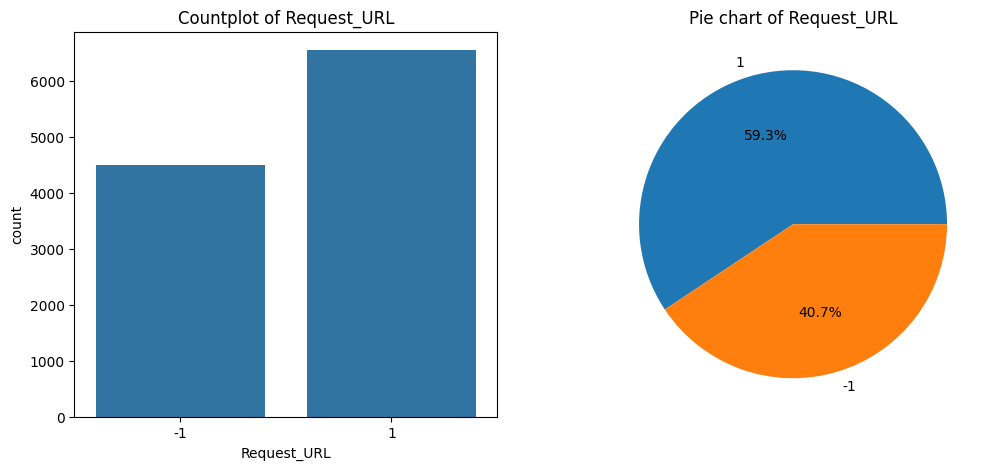

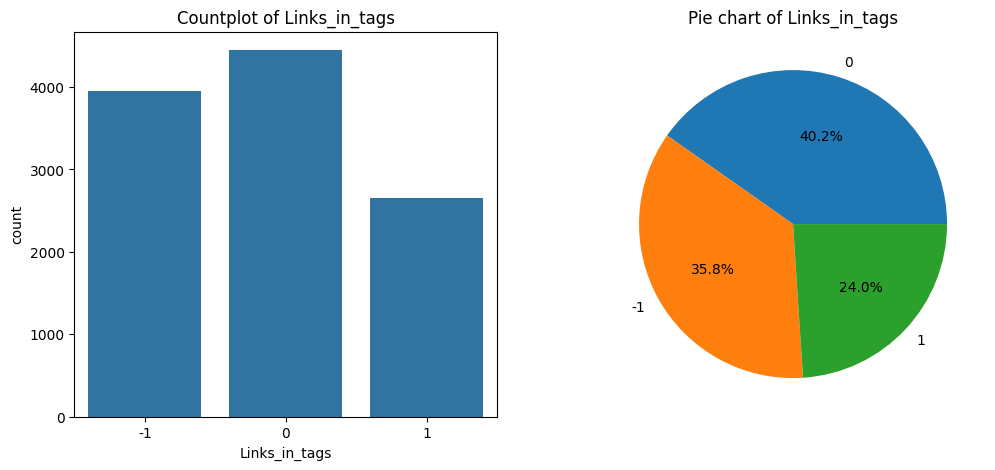

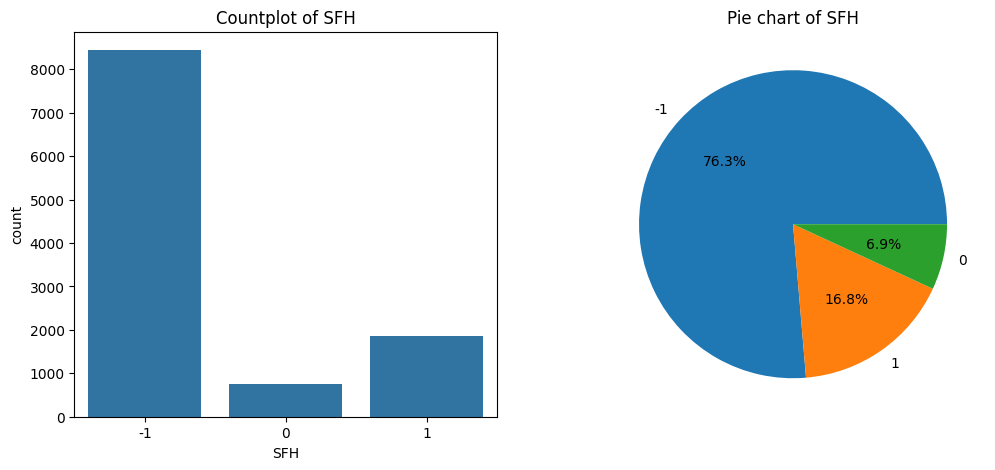

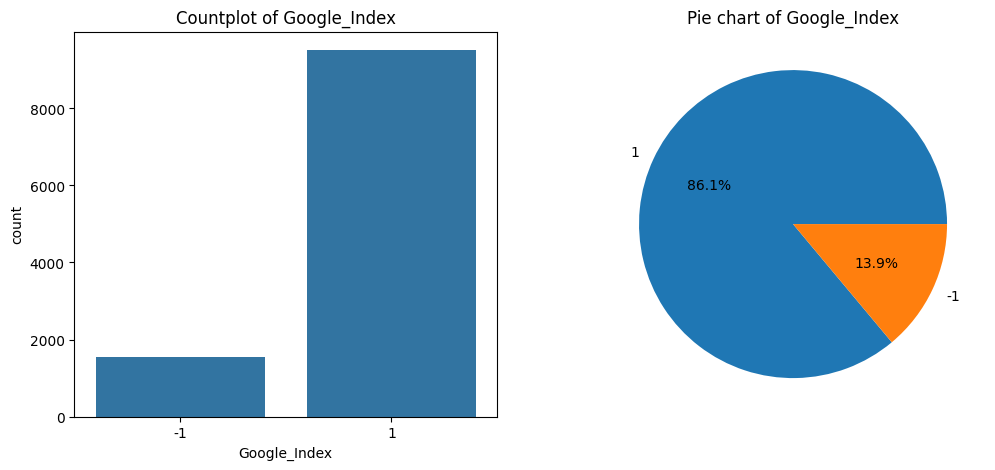

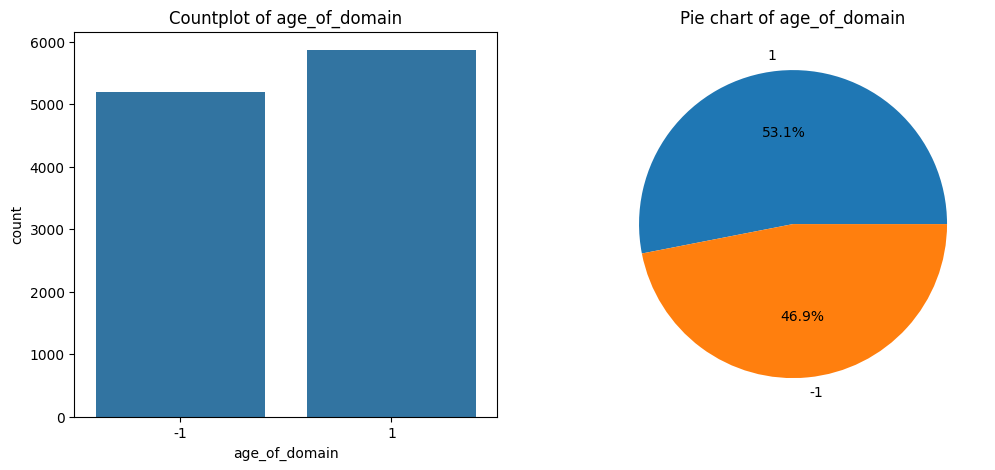

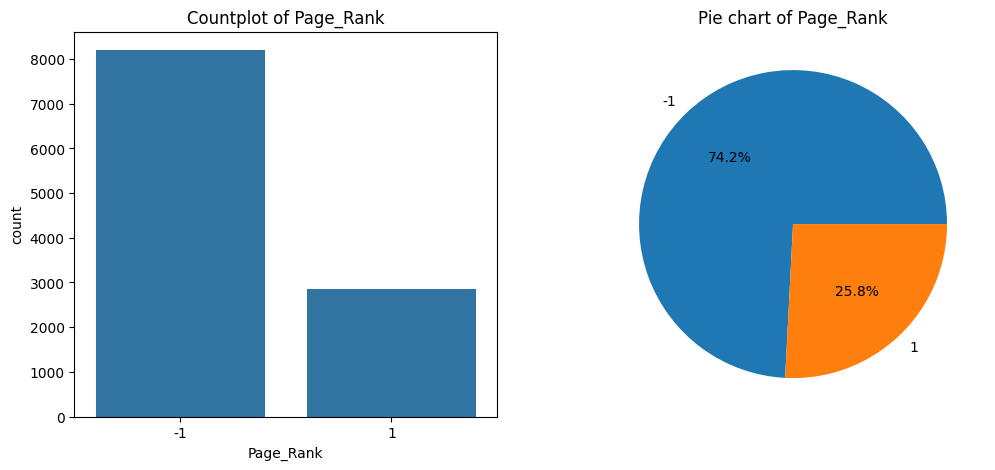

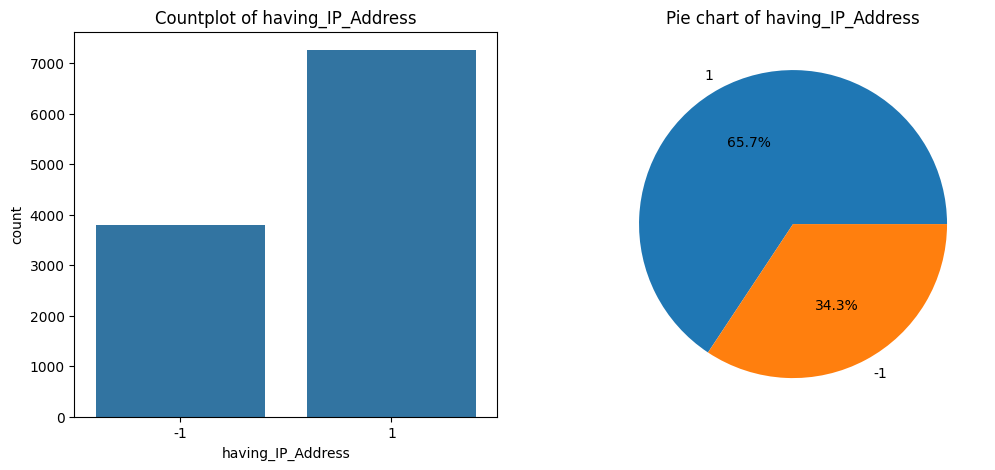

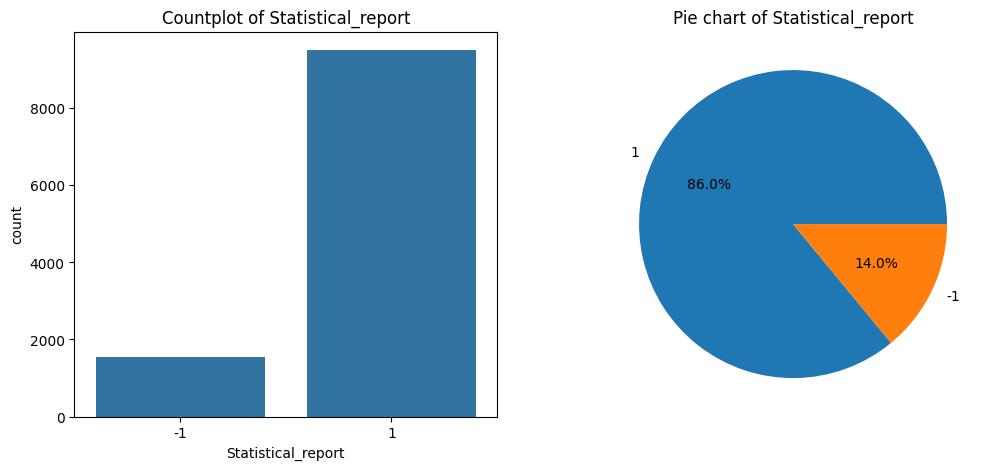

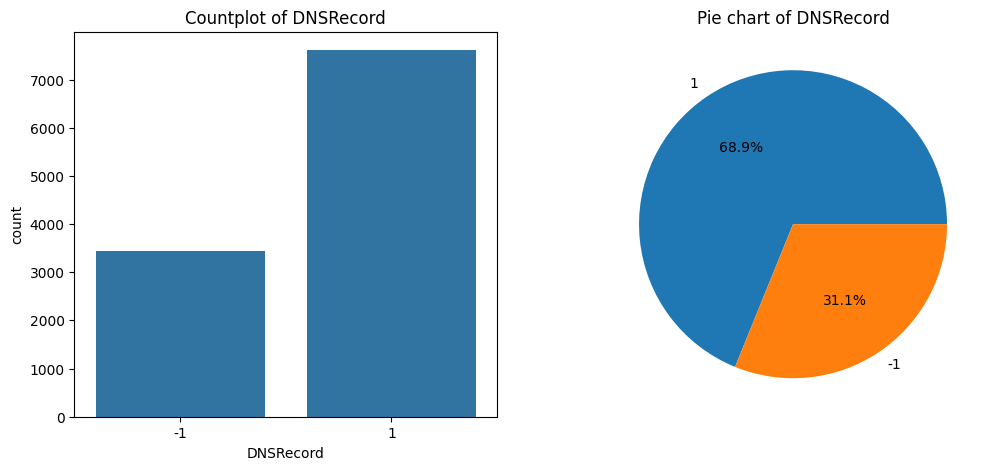

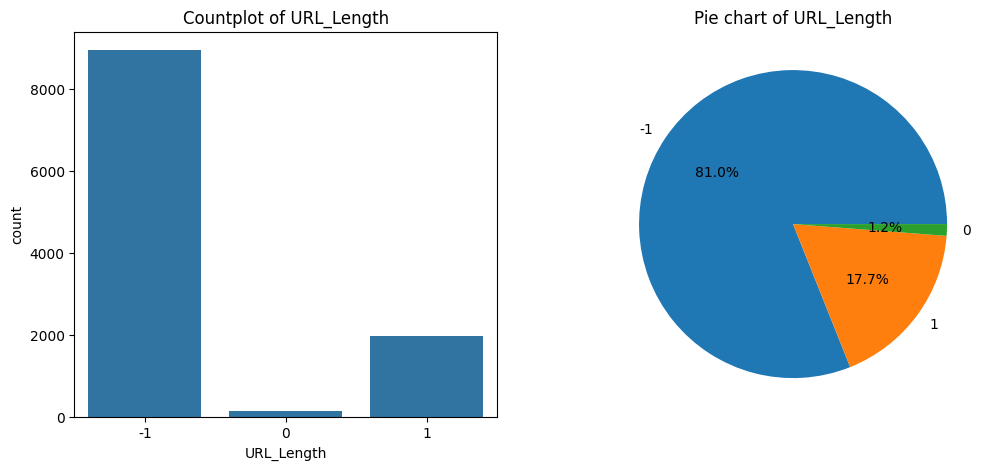

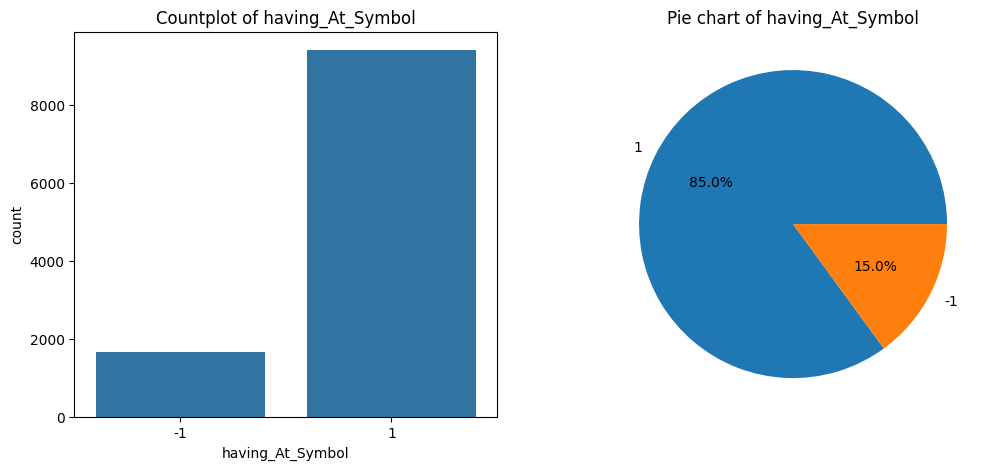

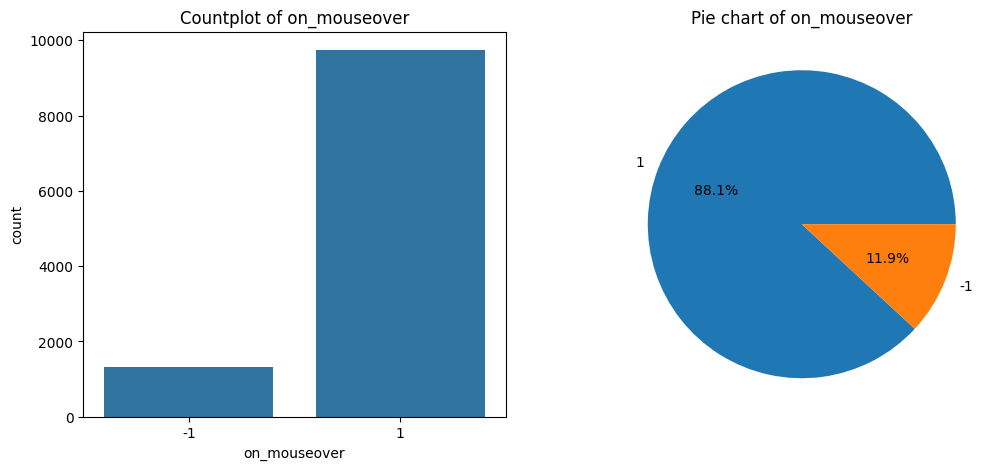

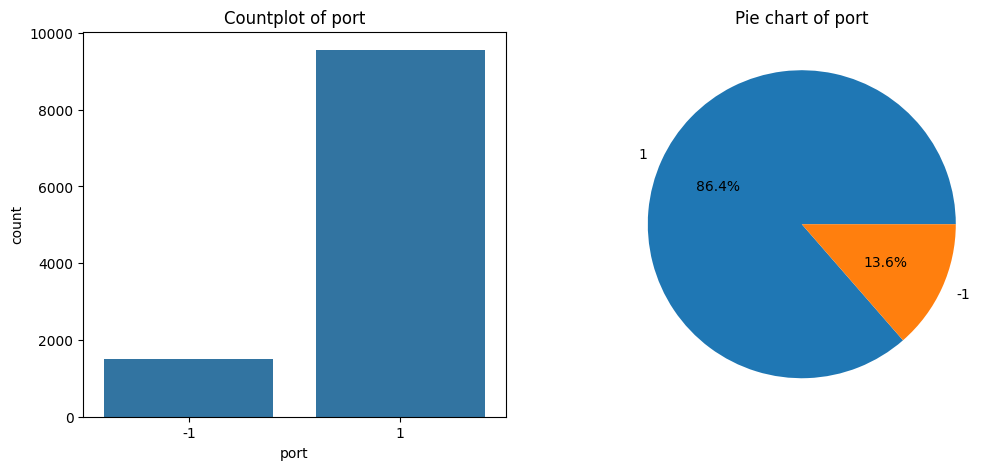

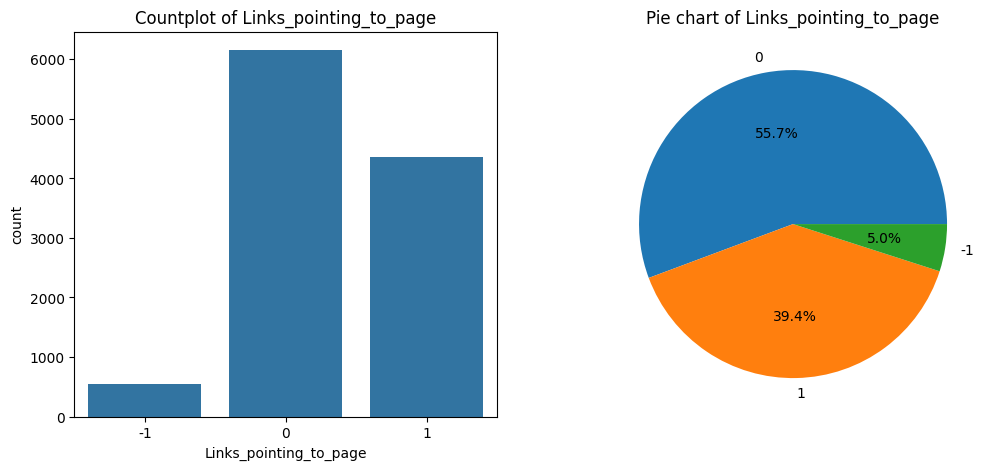

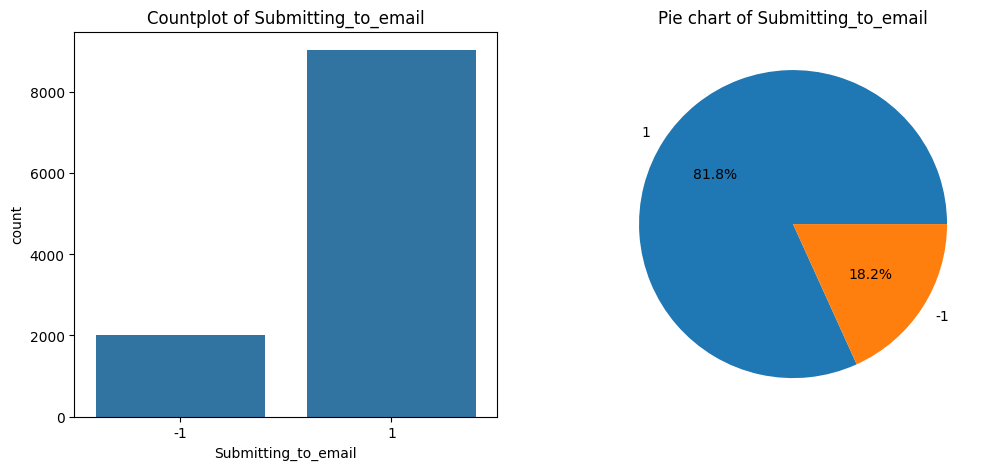

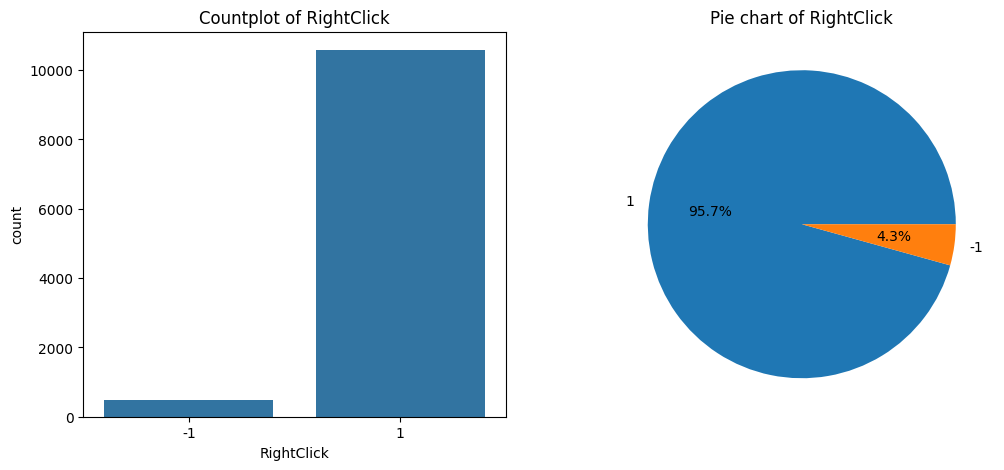

In [70]:
features = [
'Request_URL','Links_in_tags','SFH','Google_Index','age_of_domain',
'Page_Rank','having_IP_Address','Statistical_report','DNSRecord',
'URL_Length','having_At_Symbol','on_mouseover','port',
'Links_pointing_to_page','Submitting_to_email','RightClick'
]

for col in features:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.countplot(data=data, x=col)
    plt.title(f'Countplot of {col}')

    plt.subplot(1,2,2)
    data[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Pie chart of {col}')
    plt.ylabel('')

    plt.show()

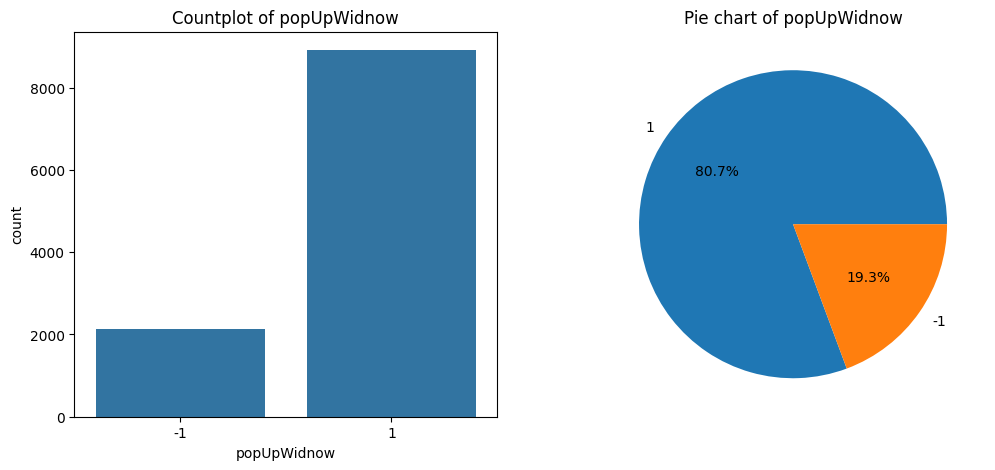

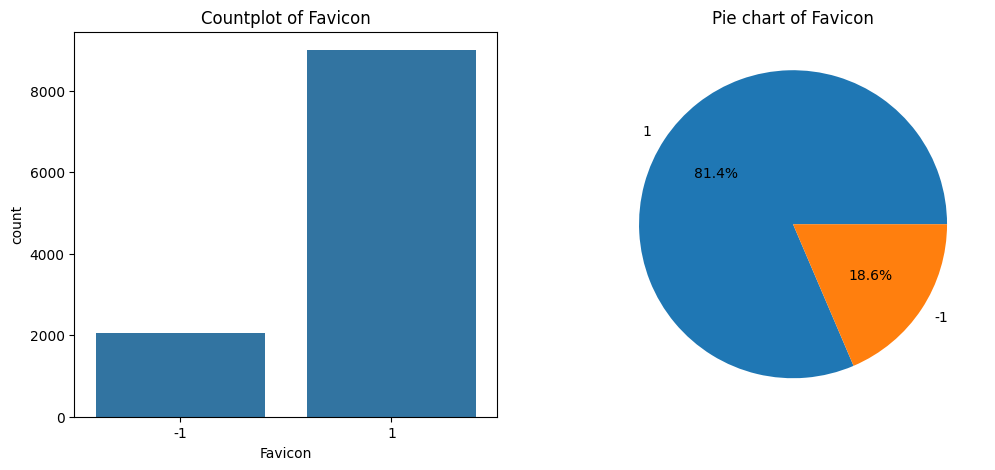

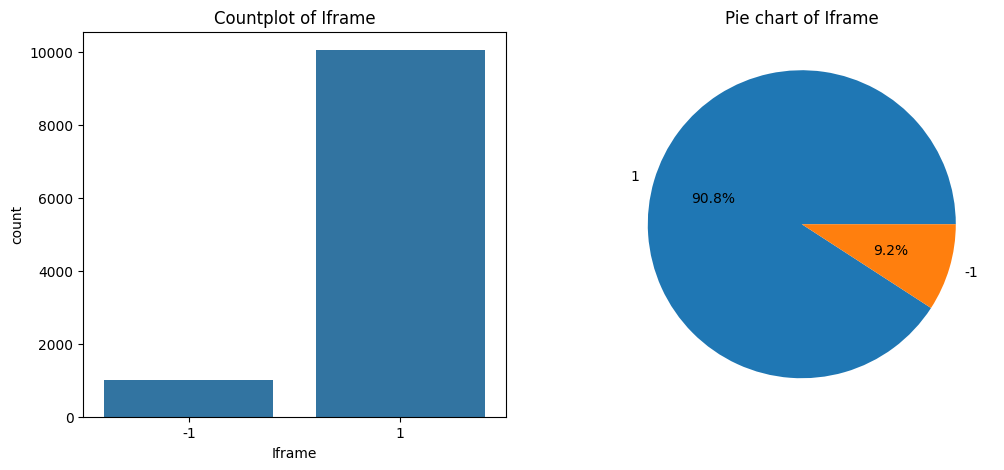

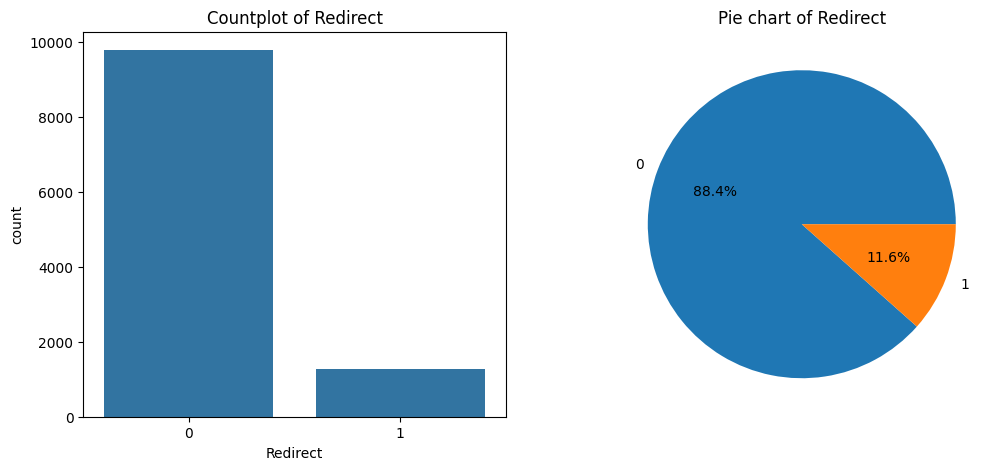

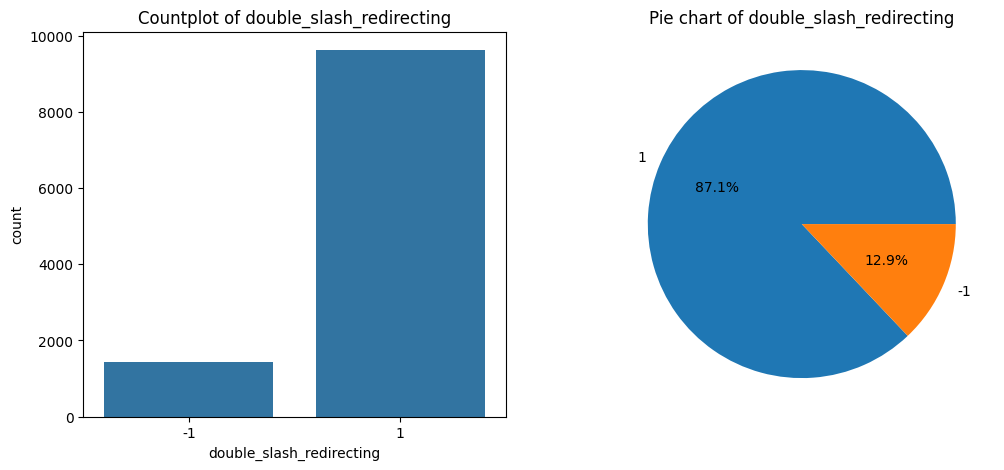

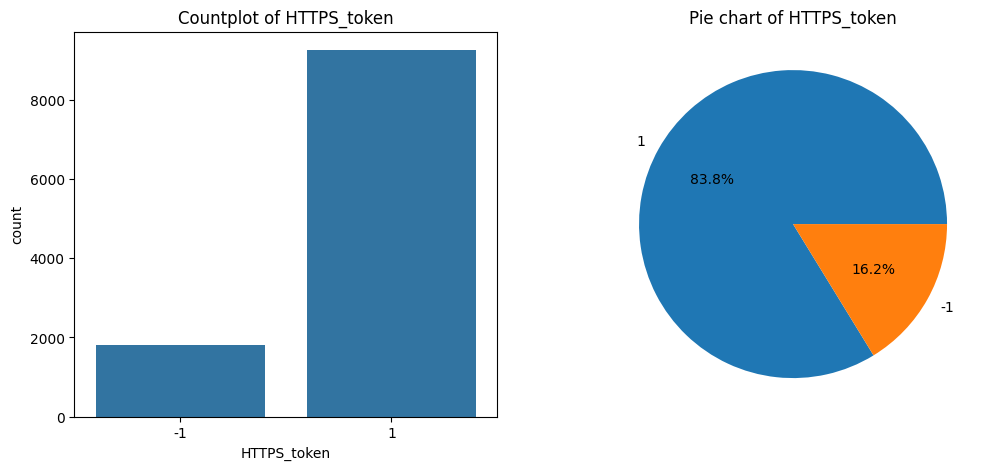

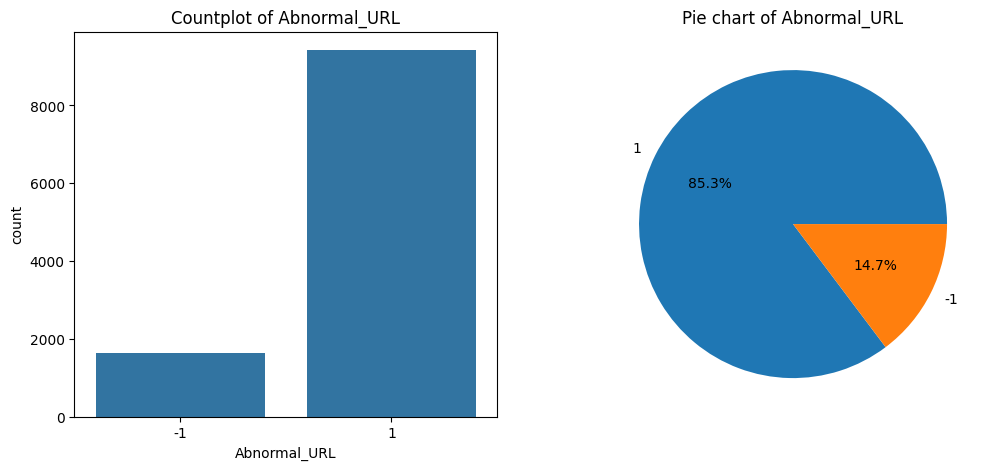

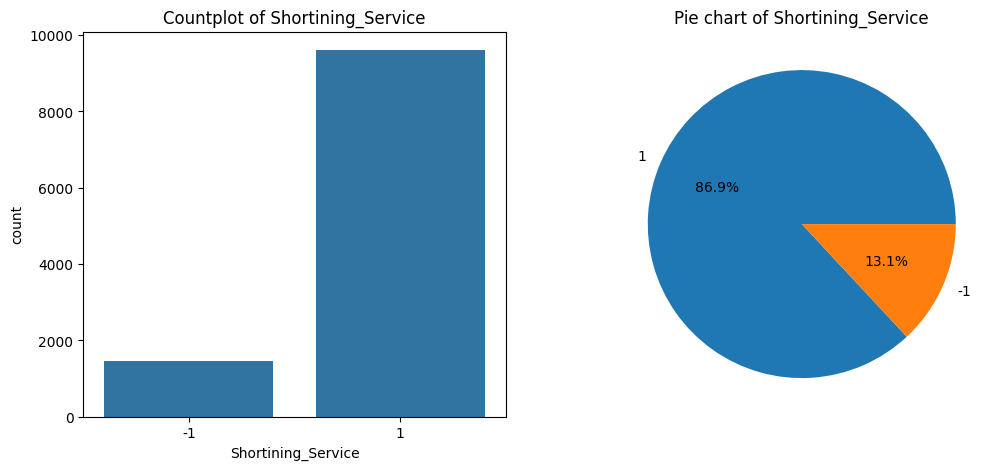

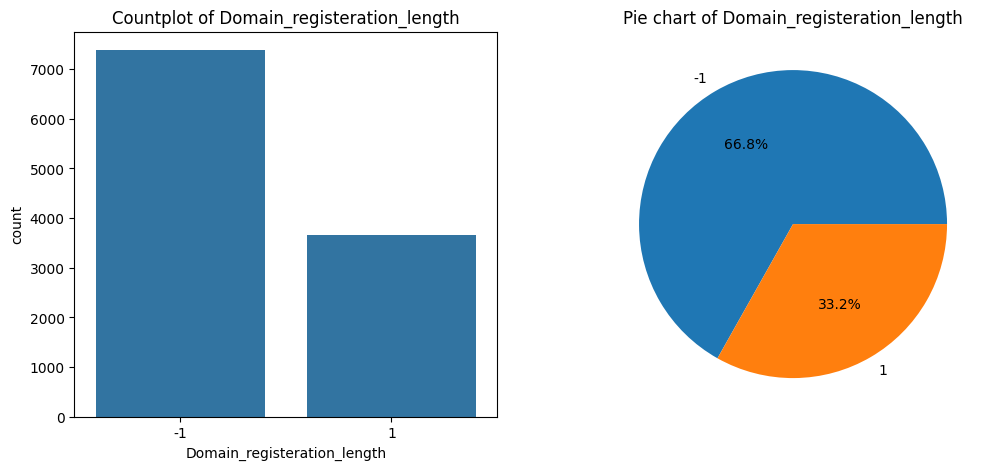

In [71]:
features = [
'popUpWidnow','Favicon','Iframe','Redirect',
'double_slash_redirecting','HTTPS_token',
'Abnormal_URL','Shortining_Service',
'Domain_registeration_length'
]

for col in features:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.countplot(data=data, x=col)
    plt.title(f'Countplot of {col}')

    plt.subplot(1,2,2)
    data[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Pie chart of {col}')
    plt.ylabel('')

    plt.show()

## multivariate

In [72]:
pd.crosstab(data['SSLfinal_State'],data['Result'],normalize=True)

Result,-1,1
SSLfinal_State,,
-1,0.275984,0.045771
0,0.103664,0.001900
1,0.063410,0.509272


In [73]:
pd.crosstab(data['SSLfinal_State'],data['Result'])

Result,-1,1
SSLfinal_State,,
-1,3051,506
0,1146,21
1,701,5630


In [74]:
pd.crosstab([data['having_IP_Address'],data['having_Sub_Domain']],data['Result'],normalize=True)

Result                                     -1         1
having_IP_Address having_Sub_Domain                    
-1                -1                 0.047218  0.035278
                   0                 0.092809  0.032022
                   1                 0.034193  0.101583
 1                -1                 0.118860  0.102849
                   0                 0.110900  0.091904
                   1                 0.039077  0.193306

In [75]:
pd.crosstab([data['DNSRecord'],data['age_of_domain']],data['Result'],normalize=True)

Result                         -1         1
DNSRecord age_of_domain                    
-1        -1             0.085934  0.052374
           1             0.069471  0.103664
 1        -1             0.152148  0.178924
           1             0.135504  0.221981

In [76]:
pd.crosstab([data['URL_of_Anchor'],data['Links_pointing_to_page']],data['Result'],normalize=True)

Result                                      -1         1
URL_of_Anchor Links_pointing_to_page                    
-1            -1                      0.010041  0.000905
               0                      0.171597  0.000000
               1                      0.111986  0.002352
 0            -1                      0.007056  0.023790
               0                      0.085663  0.179466
               1                      0.043148  0.143645
 1            -1                      0.000362  0.007417
               0                      0.007689  0.112438
               1                      0.005518  0.086929

In [77]:
pd.crosstab([data['popUpWidnow'],data['on_mouseover']],data['Result'],normalize=True)

Result                          -1         1
popUpWidnow on_mouseover                    
-1          -1            0.058073  0.058706
             1            0.027589  0.048937
 1          -1            0.001357  0.000814
             1            0.356038  0.448485

In [78]:
pd.crosstab([data['Request_URL'],data['Links_in_tags']],data['Result'],normalize=True)

Result                           -1         1
Request_URL Links_in_tags                    
-1          -1             0.122207  0.044414
             0             0.080868  0.065853
             1             0.038896  0.054365
 1          -1             0.093713  0.097512
             0             0.076888  0.178833
             1             0.030484  0.115966

In [79]:
data.sample(5)

,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
7004,7005,-1,1,1,1,1,-1,0,1,-1,...,1,1,1,1,1,-1,1,1,1,1
8782,8783,1,-1,1,1,1,1,0,1,1,...,-1,-1,-1,1,-1,-1,1,0,1,1
6354,6355,1,-1,1,1,1,1,-1,1,1,...,-1,-1,-1,1,-1,-1,1,0,1,1
2859,2860,1,-1,1,1,1,-1,1,1,-1,...,1,1,1,1,1,-1,-1,-1,-1,1
6808,6809,-1,-1,-1,1,-1,-1,1,1,-1,...,1,1,-1,-1,1,-1,-1,1,1,1


In [80]:
corr = data.corr(numeric_only=True)
corr['Result']

id                             0.000978
having_IP_Address              0.094160
URL_Length                     0.057430
Shortining_Service            -0.067966
having_At_Symbol               0.052948
double_slash_redirecting      -0.038608
Prefix_Suffix                  0.348606
having_Sub_Domain              0.298323
SSLfinal_State                 0.714741
Domain_registeration_length   -0.225789
Favicon                       -0.000280
port                           0.036419
HTTPS_token                   -0.039854
Request_URL                    0.253372
URL_of_Anchor                  0.692935
Links_in_tags                  0.248229
SFH                            0.221419
Submitting_to_email            0.018249
Abnormal_URL                  -0.060488
Redirect                      -0.020113
on_mouseover                   0.041838
RightClick                     0.012653
popUpWidnow                    0.000086
Iframe                        -0.003394
age_of_domain                  0.121496


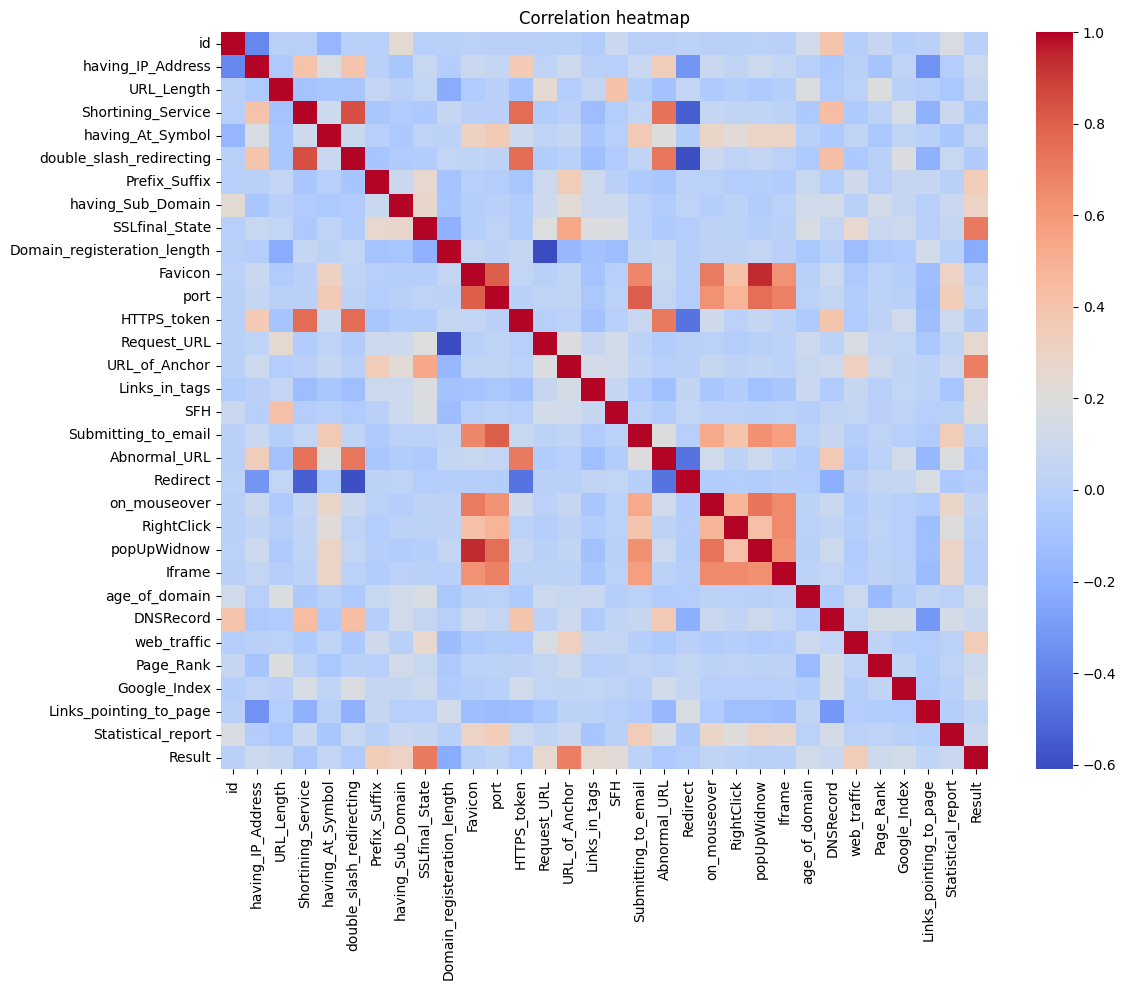

In [81]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [82]:
y=data['Result']
x=data.drop(columns=['id','Result','Favicon','Page_Rank','Links_pointing_to_page'])
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [97]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
y_pred=rf.predict(x_test)

In [85]:
accuracy_score(y_test,y_pred)

0.9669832654907282

In [86]:
confusion_matrix(y_test,y_pred)

array([[ 944,   36],
       [  37, 1194]])

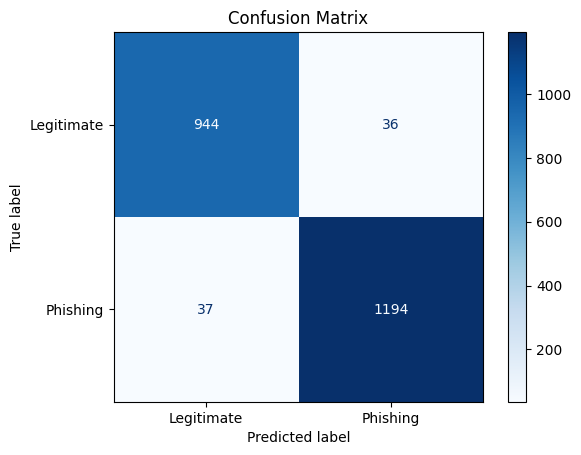

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Legitimate", "Phishing"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

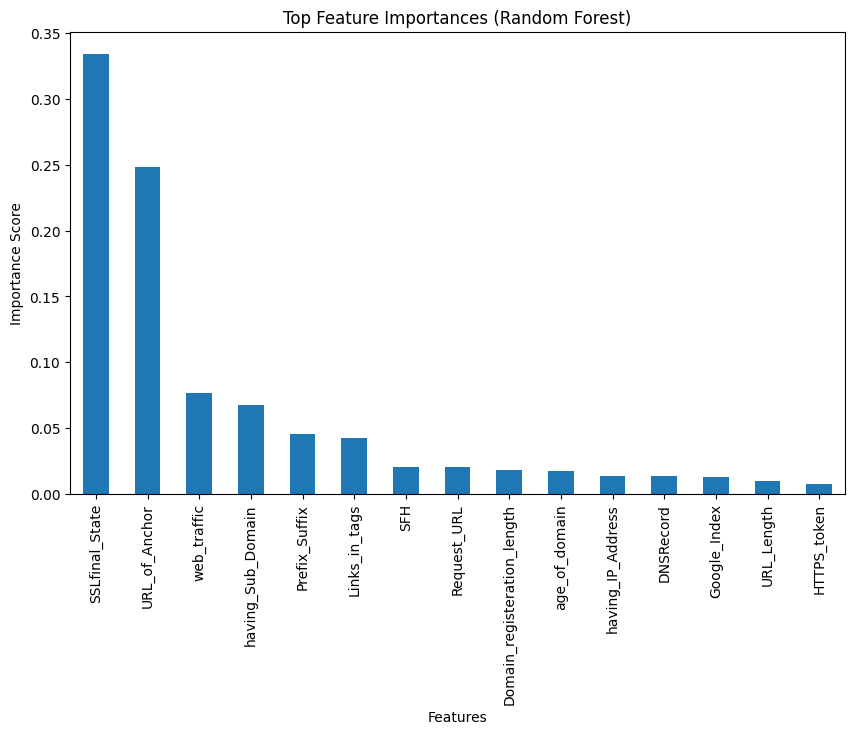

In [88]:
importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
)

importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
importance.head(15).plot(kind="bar")

plt.title("Top Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Features")

plt.show()

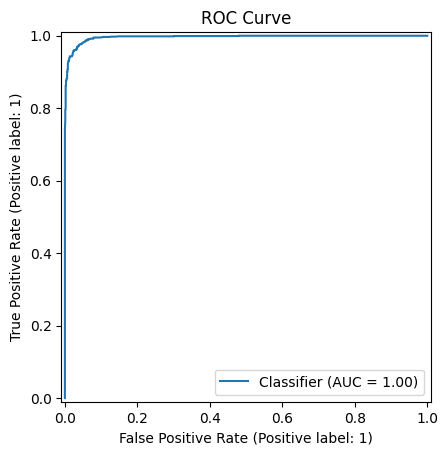

In [89]:
y_prob = rf.predict_proba(x_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")
plt.show()

In [93]:
with open('phishing.pkl','wb') as f:
    pickle.dump(rf,f)

In [94]:
with open('phishing.pkl','rb') as f:
    model=pickle.load(f)

In [95]:
model

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
x.columns

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags',
       'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect',
       'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain',
       'DNSRecord', 'web_traffic', 'Google_Index', 'Statistical_report'],
      dtype='object')

In [98]:
print('hi')

hi


In [ ]:
x_train